# Generate melt dates using a threshold-based method for intercomparison
This code derives the melt onset date (MOD) and melt end date (MED) from passive microwave brightness temperature differences (ΔTb) obtained from SMMR, SSM/I, and SSMIS sensors, following the threshold-based approach of Wang et al. (2013) (see https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/grl.50098).

Although some implementation details may differ from the original study, the method was carefully implemented to closely adhere to the procedure described in Wang et al. (2013).

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
import subprocess
from shapely.geometry import Point

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Create the land mask for regions north of 60°N

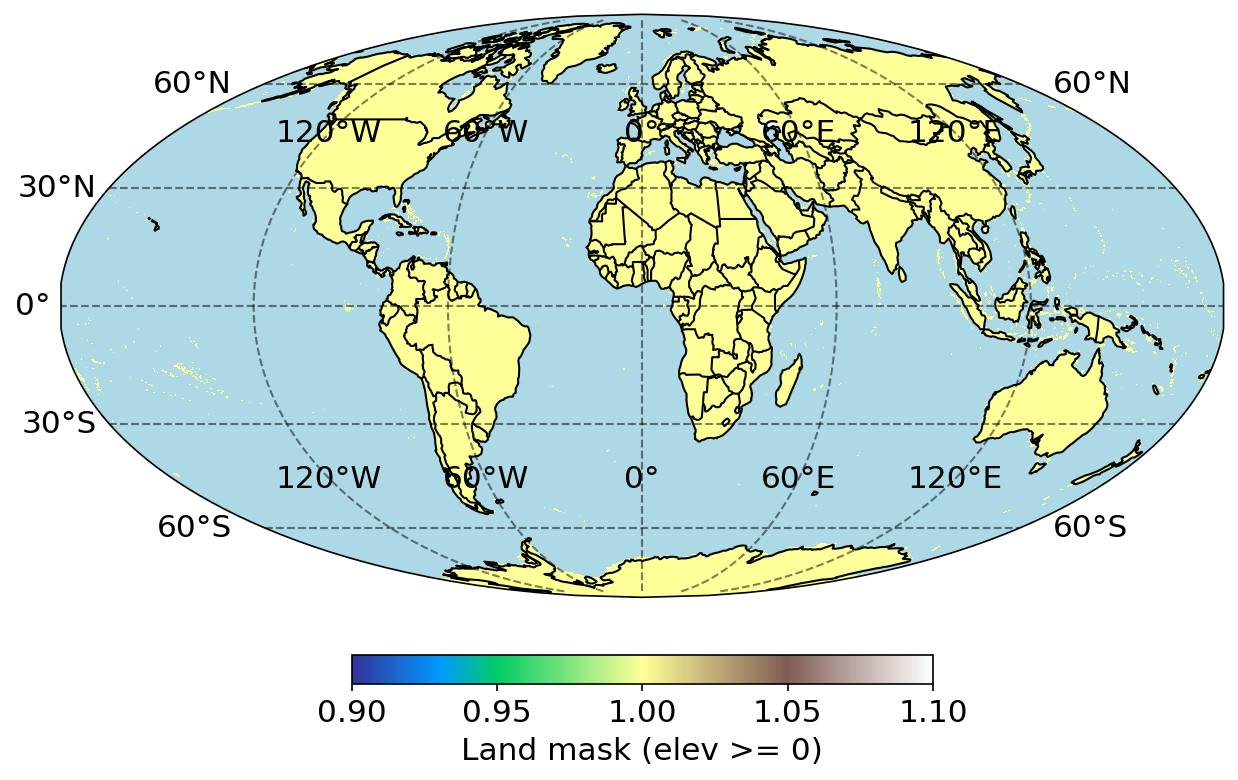

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Calculation of MOD using the threshold-based method
Following the approach described in Wang et al. (2013), the melt onset date (MOD) is identified based on changes in passive microwave brightness temperature difference (ΔTb). 

Specifically, MOD is detected when the difference between the daily ΔTb and its preceding 3-day moving average (M) exceeds a threshold (TH1 = 0.35 × M) for at least four consecutive days.

In [4]:
# Define functions
def is_leap_year(year):
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)


def divide_tb_diff_by_year(tb_diff, start_year=1988, end_year=2022):
    tb_by_year = {}
    t0 = 0

    for year in range(start_year, end_year + 1):
        ndays = 366 if is_leap_year(year) else 365
        
        tb_by_year[year] = tb_diff[:, :, t0:t0 + ndays]
        t0 += ndays

    return tb_by_year


def calculate_wang_mod(tb_diff_by_year, start_year=1988, end_year=2022,
                       alpha=0.35, consec_days=4):

    MOD_by_year = {}

    for year in range(start_year, end_year + 1):
        x = tb_diff_by_year[year]  # (lat, lon, ndays)
        ndays = x.shape[2]

        # Compute the preceding 3-day moving average (M)
        # M(t) is defined as the mean of ΔTb over the previous 3 days (t-3 to t-1)
        previous_3_day_average = np.full_like(x, np.nan, dtype=np.float32)
        for t in range(3, ndays): # Valid only for t>=3
            previous_3_day_average[:, :, t] = np.nanmean(x[:, :, t-3:t], axis=2)

        # Construct condition array C(t)
        # C(t) = True if ΔTb(t) - M(t) > α × M(t)
        # where α = 0.35 following Wang et al. (2013)
        C = (x - previous_3_day_average) > (alpha * previous_3_day_average)

        # Detect MOD (Melt Onset Date)
        # MOD is defined as the first day when C(t) holds for at least 4 consecutive days 
        mod = np.full((x.shape[0], x.shape[1]), np.nan, dtype=np.float32)

        # Iterate over time ensuring a full consecutive window is available
        for t in range(3, ndays - consec_days + 1):
            # Check if condition is satisfied for 'consec_days' consecutive days
            run_ok = np.all(C[:, :, t:t+consec_days], axis=2)

            # Assign only the first occurrence (earliest MOD)
            new = run_ok & np.isnan(mod)
            mod[new] = t + 1  # Convert to 1-based DOY

        MOD_by_year[year] = mod

    return MOD_by_year


def apply_masks_to_MD_by_year( # MD = Melt Date
    wang_md_by_year: dict,
    year_for_mask: int,
    landmask=None,
    cpuserver_data_FP=None,
):

    if not isinstance(wang_md_by_year, dict):
        raise TypeError("wang_md_by_year must be dict {year: (H,W)}")

    mask_year = 1992 if year_for_mask <= 1992 else year_for_mask
    mask_file = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask/Permafrost_waterbody_mask_25km_{mask_year}.nc"

    with nc.Dataset(mask_file, "r") as ds:
        snowice_mask = ds.variables["snowice_mask"][:]
        water_mask   = ds.variables["water_mask"][:]

        # Convert masked arrays to ndarray with NaN
        snowice_mask = np.ma.filled(snowice_mask, np.nan).astype(float)
        water_mask   = np.ma.filled(water_mask,   np.nan).astype(float)

    common_mask = np.isnan(snowice_mask) | np.isnan(water_mask)  # True -> mask out

    out = {}
    for yr, md2d in wang_md_by_year.items():
        md2d = np.asarray(md2d, float)

        if md2d.shape != common_mask.shape:
            raise ValueError(f"Shape mismatch year={yr}: mod {md2d.shape} vs mask {common_mask.shape}")

        masked = np.where(common_mask, np.nan, md2d)

        if landmask is not None:
            masked = np.where((landmask == 1) & np.isfinite(landmask), masked, np.nan)

        out[yr] = masked.astype(np.float32)

    return out


In [5]:
TB_difference_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Brightness_Temperature/Final_TB_difference.nc'

# Load TB difference data
with nc.Dataset(TB_difference_path, "r") as ds:
    lat = ds.variables['lat'][:]
    lon = ds.variables['lon'][:]
    tb = ds.variables['tb_diff'][:]
    tb = ds.variables['tb_diff'][:].astype(float)
    tb = np.ma.filled(tb, np.nan)
    tb[tb == -999999] = np.nan
    tb_diff = tb / 10000.0

In [6]:
# Setting
start_year, end_year = 1988, 2022

# Apply the threshold-based method
tb_diff_by_year = divide_tb_diff_by_year(tb_diff, 1988, 2022)
wang_mod_by_year = calculate_wang_mod(tb_diff_by_year, 1988, 2022, alpha=0.35, consec_days=4)

# Apply the mask
for year in range(start_year, end_year + 1):
    wang_mod_by_year = apply_masks_to_MD_by_year(
        wang_mod_by_year,
        year_for_mask=year,
        landmask=land_mask_60N_base,
        cpuserver_data_FP=cpuserver_data_FP,
    )


### Save calculated MOD as NC file

In [7]:
# Save the calculated MOD
years = sorted(wang_mod_by_year.keys())
nyear = len(years)
nlat, nlon = wang_mod_by_year[years[0]].shape
out_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MOD_by_year.nc"

with nc.Dataset(out_path, "w", format="NETCDF4") as ds:
    # Dimensions
    ds.createDimension("year", nyear)
    ds.createDimension("lat", nlat)
    ds.createDimension("lon", nlon)

    # Coordinates
    vyear = ds.createVariable("year", "i4", ("year",))
    vlat  = ds.createVariable("lat",  "f4", ("lat",))
    vlon  = ds.createVariable("lon",  "f4", ("lon",))

    vyear[:] = years
    vlat[:]  = lat[:]     
    vlon[:]  = lon[:]     

    vyear.units = "year"
    vlat.units  = "degrees_north"
    vlon.units  = "degrees_east"

    # Data variable
    vmod = ds.createVariable(
        "MOD_doy",
        "f4",
        ("lat", "lon", "year"),
        zlib=True,
        complevel=4,
        fill_value=np.nan
    )

    for yi, y in enumerate(years):
        vmod[:, :, yi] = wang_mod_by_year[y]

print("Saved:", out_path)


Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MOD_by_year.nc


### Verify that the calculated MOD meets the criteria described in the paper

Selected pixel: lat idx=61, lon idx=273


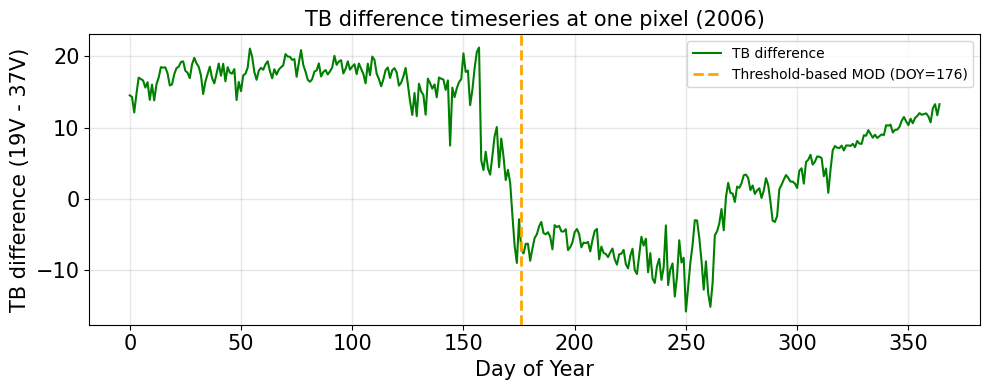

Day 176 (idx=175): TB=-2.8499, prev3=-5.9299, diff=3.0800, thr=-2.0755 -> OK
Day 177 (idx=176): TB=-7.1298, prev3=-6.1232, diff=-1.0066, thr=-2.1431 -> OK
Day 178 (idx=177): TB=-7.6500, prev3=-6.3199, diff=-1.3301, thr=-2.2120 -> OK
Day 179 (idx=178): TB=-6.3000, prev3=-5.8766, diff=-0.4234, thr=-2.0568 -> OK

Satisfies the criteria for 4 consecutive days starting at MOD (DOY 176)


In [8]:
# Load the calculated MOD
Threshold_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MOD_by_year.nc'
with nc.Dataset(Threshold_MOD_path, "r") as ds:
    lat = ds["lat"][:]
    lon = ds["lon"][:]
    MOD_doy = ds["MOD_doy"][:]

# Select the pixel and year that I want to see
start_year = 1988
target_year = 2006
MOD_target_year = MOD_doy[:, :, target_year - start_year]

# Find valid pixels where MOD is not nan
valid_idx = np.where(np.isfinite(MOD_target_year))

# Randomly select one pixel
i = np.random.randint(len(valid_idx[0]))
lat_i = valid_idx[0][i]
lon_i = valid_idx[1][i]
print(f"Selected pixel: lat idx={lat_i}, lon idx={lon_i}")

# Extract the pixel's timeseries of tb_diff and MOD
tb_ts = tb_diff_by_year[target_year][lat_i, lon_i, :] 
mod_doy = MOD_target_year[lat_i, lon_i]
idx_mod = int(mod_doy - 1)

# Plot the timeseries
plt.figure(figsize=(10, 4))
plt.plot(tb_ts, color='green', lw=1.5, label='TB difference')

# MOD vertical line
plt.axvline(mod_doy, color='orange', lw=2, linestyle='--',
            label=f'Threshold-based MOD (DOY={int(mod_doy)})')

plt.xlabel("Day of Year")
plt.ylabel("TB difference (19V - 37V)")
plt.title(f"TB difference timeseries at one pixel ({target_year})")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

########################################################################################################################
# Check if the MOD satisfies the criteria
n_consec = 4

# Ensure MOD is valid and convert DOY to integer index
mod_doy_raw = mod_doy
if not np.isfinite(mod_doy_raw):
    raise ValueError("MOD is NaN at this pixel.")

mod_doy = int(np.round(mod_doy_raw)) 
idx_mod = int(mod_doy - 1)
tb = tb_ts
nt = tb.shape[0]

# Check boundary conditions for applying the 4-day consecutive rule
if mod_doy < 4:
    print("Warning: mod_doy < 4, cannot evaluate 4-day consecutive criteria (needs 3 days before each day).")
elif idx_mod + (n_consec - 1) >= nt:
    print("Warning: Not enough days after MOD to check 4 consecutive days.")
else:
    all_ok = True

    # Evaluate the threshold condition for each of the consecutive days
    for k in range(n_consec):
        idx = int(idx_mod + k)
        tb_day = tb[idx] # ΔTb at day t
        tb_prev3 = np.nanmean(tb[idx-3:idx])  # M(t): previous 3-day mean

        diff = tb_day - tb_prev3 # ΔTb(t) - M(t)
        thr  = 0.35 * tb_prev3 # Threshold: 0.35 × M(t)

        # Check validity and threshold condition
        ok = np.isfinite(tb_day) and np.isfinite(tb_prev3) and (diff > thr)

        print(f"Day {mod_doy + k} (idx={idx}): TB={tb_day:.4f}, prev3={tb_prev3:.4f}, "
              f"diff={diff:.4f}, thr={thr:.4f} -> {'OK' if ok else 'NO'}")

        if not ok:
            all_ok = False

    # Final validation result
    if all_ok:
        print(f"\nSatisfies the criteria for {n_consec} consecutive days starting at MOD (DOY {mod_doy})")
    else:
        print(f"\nDoes NOT satisfy the criteria for {n_consec} consecutive days starting at MOD (DOY {mod_doy})")


## Calculation of MED using a threshold-based method
Following Wang et al. (2013), the melt end date (MED) is derived from passive microwave brightness temperature differences (ΔTb). MED is defined as the first day on which daily ΔTb falls below a threshold (TH2) for a sustained period.

- MED is detected when daily ΔTb is lower than TH2 for at least **28 consecutive days**.
- If this condition is not satisfied at a given grid cell, the required duration is relaxed sequentially to:
  - **21 consecutive days**, and then  
  - **14 consecutive days**, if necessary.

The threshold TH2 is defined as:

- **TH2 = (mean ΔTb in July) + 7 K**

This threshold was selected based on empirical testing, yielding the best agreement with observational datasets.

In [9]:
## Define functions
# A function that checks whether all values within a sliding window of length k along the time axis are True
def _rolling_true_run(b: np.ndarray, k: int) -> np.ndarray:
    # Cumulative sum over time axis
    cs = np.cumsum(b.astype(np.int16), axis=2)

    # Sum over window [t, t+k)
    win_sum = cs[:, :, k-1:] - np.concatenate(
        [np.zeros(cs[:, :, :1].shape, dtype=cs.dtype), cs[:, :, :-k]],
        axis=2
    )
    return win_sum == k


# A function that calculates the MED using a threshold-based method
def calculate_wang_med(
    tb_diff_by_year,
    start_year=1988,
    end_year=2022,
    continuous_days=(28, 21, 14),
    july_offset=7.0,
):
    MED_by_year = {}

    for year in range(start_year, end_year + 1):
        x = np.asarray(tb_diff_by_year[year], float)  # (H,W,T)
        if x.ndim != 3:
            raise ValueError(f"tb_diff_by_year[{year}] must be 3D (H,W,T), got {x.shape}")

        H, W, T = x.shape

        # July mean 
        if is_leap_year(year):
            july = x[:, :, 182:213]  # DOY183..213 (31 days) -> indices 182..212
        else:
            july = x[:, :, 181:212]  # DOY182..212 (31 days) -> indices 181..211

        july_avg = np.nanmean(july, axis=2)          # (H,W)
        th2 = july_avg + float(july_offset)          # (H,W)

        # Condition: TbD < TH2 and finite
        b = np.isfinite(x) & np.isfinite(th2[:, :, None]) & (x < th2[:, :, None])  # (H,W,T)

        med = np.full((H, W), np.nan, dtype=np.float32)  # final MED map

        # Try 28 -> 21 -> 14 for pixels not yet detected
        for k in continuous_days:
            k = int(k)
            if k <= 0 or k > T:
                continue

            need = ~np.isfinite(med)  # pixels still undetected
            if not np.any(need):
                break

            run_ok = _rolling_true_run(b, k)  # (H,W,T-k+1)

            # Only care for pixels in `need`
            ok_need = run_ok[need, :]                 # (Npix, T-k+1)
            any_ok = ok_need.any(axis=1)              # (Npix,)

            if np.any(any_ok):
                first_idx = np.argmax(ok_need, axis=1)  # returns 0 if all False
                doy = (first_idx + 1).astype(np.float32)  # 1-based DOY of window start
                tmp = med[need]
                tmp[any_ok] = doy[any_ok]
                med[need] = tmp

        MED_by_year[year] = med

    return MED_by_year

In [10]:
# Define the start and end year
start_year, end_year = 1988, 2022

# Calculate the MED
wang_med_by_year = calculate_wang_med(tb_diff_by_year, start_year=1988, end_year=2022,
                                      continuous_days=(28, 21, 14), july_offset=7.0)

# Apply the mask
for year in range(start_year, end_year + 1):
    wang_med_by_year = apply_masks_to_MD_by_year(
        wang_med_by_year,
        year_for_mask=year,
        landmask=land_mask_60N_base,
        cpuserver_data_FP=cpuserver_data_FP,
    )

### Save calculated MED as nc file

In [11]:
# Save the calculated MED
years = sorted(wang_med_by_year.keys())
nyear = len(years)
nlat, nlon = wang_med_by_year[years[0]].shape
out_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MED_by_year.nc"

with nc.Dataset(out_path, "w", format="NETCDF4") as ds:
    # Dimensions
    ds.createDimension("year", nyear)
    ds.createDimension("lat", nlat)
    ds.createDimension("lon", nlon)

    # Coordinates
    vyear = ds.createVariable("year", "i4", ("year",))
    vlat  = ds.createVariable("lat",  "f4", ("lat",))
    vlon  = ds.createVariable("lon",  "f4", ("lon",))

    vyear[:] = years
    vlat[:]  = lat[:]     
    vlon[:]  = lon[:]     

    vyear.units = "year"
    vlat.units  = "degrees_north"
    vlon.units  = "degrees_east"

    # Data variable
    vmod = ds.createVariable(
        "MED_doy",
        "f4",
        ("lat", "lon", "year"),
        zlib=True,
        complevel=4,
        fill_value=np.nan
    )

    for yi, y in enumerate(years):
        vmod[:, :, yi] = wang_med_by_year[y]

print("Saved:", out_path)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MED_by_year.nc


Selected pixel: lat idx=98, lon idx=323
July mean ΔTb = -2.4967
TH2 = July mean ΔTb + 7 K = 4.5033


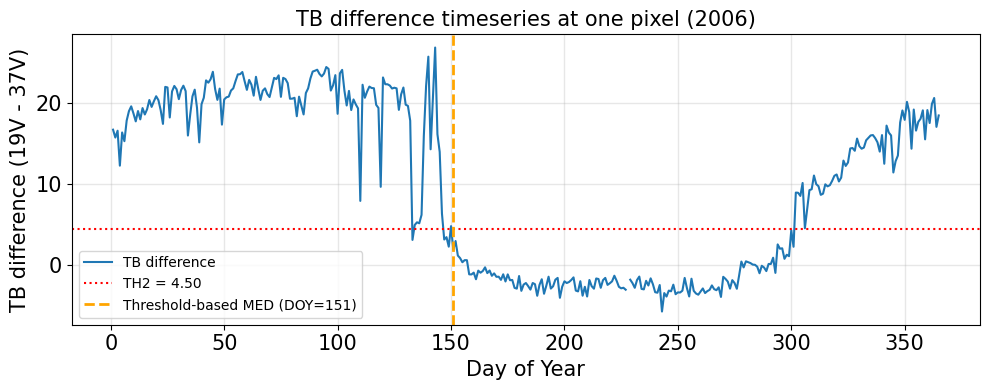


Detected MED satisfies the 28-day consecutive criterion.

Day 151 (idx=150): TB=1.9249, TH2=4.5033, TB-TH2=-2.5784 -> OK
Day 152 (idx=151): TB=3.0099, TH2=4.5033, TB-TH2=-1.4934 -> OK
Day 153 (idx=152): TB=1.2149, TH2=4.5033, TB-TH2=-3.2884 -> OK
Day 154 (idx=153): TB=0.8999, TH2=4.5033, TB-TH2=-3.6034 -> OK
Day 155 (idx=154): TB=0.3898, TH2=4.5033, TB-TH2=-4.1135 -> OK
Day 156 (idx=155): TB=0.6499, TH2=4.5033, TB-TH2=-3.8534 -> OK
Day 157 (idx=156): TB=0.6449, TH2=4.5033, TB-TH2=-3.8584 -> OK
Day 158 (idx=157): TB=-1.1000, TH2=4.5033, TB-TH2=-5.6033 -> OK
Day 159 (idx=158): TB=-1.1148, TH2=4.5033, TB-TH2=-5.6181 -> OK
Day 160 (idx=159): TB=-0.8899, TH2=4.5033, TB-TH2=-5.3932 -> OK
Day 161 (idx=160): TB=-1.7049, TH2=4.5033, TB-TH2=-6.2082 -> OK
Day 162 (idx=161): TB=-0.6449, TH2=4.5033, TB-TH2=-5.1482 -> OK
Day 163 (idx=162): TB=-0.8999, TH2=4.5033, TB-TH2=-5.4032 -> OK
Day 164 (idx=163): TB=-0.6898, TH2=4.5033, TB-TH2=-5.1931 -> OK
Day 165 (idx=164): TB=-0.2348, TH2=4.5033, TB-TH2=-4

In [12]:
# Load the calculated MED
Threshold_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MED_by_year.nc'
with nc.Dataset(Threshold_MED_path, "r") as ds:
    lat = ds["lat"][:]
    lon = ds["lon"][:]
    MED_doy = ds["MED_doy"][:]

# Select the pixel and year that I want to see
start_year = 1988
target_year = 2006
MED_target_year = MED_doy[:, :, target_year - start_year]

# Find valid pixels where MED is not nan
valid_idx = np.where(np.isfinite(MED_target_year))

# Randomly select one pixel
i = np.random.randint(len(valid_idx[0]))
lat_i = valid_idx[0][i]
lon_i = valid_idx[1][i]
print(f"Selected pixel: lat idx={lat_i}, lon idx={lon_i}")

# Extract the pixel's timeseries of tb_diff and MED
tb_ts = tb_diff_by_year[target_year][lat_i, lon_i, :]
med_doy = MED_target_year[lat_i, lon_i]
idx_med = int(med_doy - 1)

# Compute TH2 = July mean ΔTb + 7 K for this pixel
if is_leap_year(target_year):
    july_ts = tb_ts[182:213]   # Calendar July in leap year
else:
    july_ts = tb_ts[181:212]   # Calendar July in non-leap year

july_avg = np.nanmean(july_ts)
th2 = july_avg + 7.0

print(f"July mean ΔTb = {july_avg:.4f}")
print(f"TH2 = July mean ΔTb + 7 K = {th2:.4f}")

# Plot the timeseries
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(tb_ts) + 1), tb_ts, lw=1.5, label='TB difference')

# Threshold line
plt.axhline(th2, color='red', lw=1.5, linestyle=':', label=f'TH2 = {th2:.2f}')

# MED vertical line
plt.axvline(med_doy, color='orange', lw=2, linestyle='--',
            label=f'Threshold-based MED (DOY={int(med_doy)})')

plt.xlabel("Day of Year")
plt.ylabel("TB difference (19V - 37V)")
plt.title(f"TB difference timeseries at one pixel ({target_year})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

########################################################################################################################
# Check if the MED satisfies the criteria
continuous_days = (28, 21, 14)

# Ensure MED is valid and convert DOY to integer index
med_doy_raw = med_doy
if not np.isfinite(med_doy_raw):
    raise ValueError("MED is NaN at this pixel.")

med_doy = int(np.round(med_doy_raw))
idx_med = int(med_doy - 1)

tb = tb_ts
nt = tb.shape[0]

detected_k = None

# Identify which consecutive-day criterion (28, 21, or 14) was satisfied
for k in continuous_days:
    if idx_med + (k - 1) >= nt:
        continue

    all_ok = True
    for j in range(k):
        idx = idx_med + j
        tb_day = tb[idx]

        ok = np.isfinite(tb_day) and np.isfinite(th2) and (tb_day < th2)

        if not ok:
            all_ok = False
            break

    if all_ok:
        detected_k = k
        break


# Print validation result for the detected MED
if detected_k is None:
    print("The detected MED does NOT satisfy any of the criteria (28, 21, or 14 consecutive days).")
else:
    print(f"\nDetected MED satisfies the {detected_k}-day consecutive criterion.\n")

    for j in range(detected_k):
        idx = idx_med + j
        tb_day = tb[idx]
        diff = tb_day - th2
        ok = np.isfinite(tb_day) and np.isfinite(th2) and (tb_day < th2)

        print(f"Day {med_doy + j} (idx={idx}): TB={tb_day:.4f}, TH2={th2:.4f}, "
              f"TB-TH2={diff:.4f} -> {'OK' if ok else 'NO'}")

    print(f"\nSatisfies the criteria for {detected_k} consecutive days starting at MED (DOY {med_doy})")